# 03 - Riesgo por repositorio y conclusiones

## Introducción
Notebook de cierre orientado a priorización: valida el consolidado, compara señales de riesgo y sintetiza conclusiones para reporte.
Incluye verificación contra datos raw del Miner para mantener trazabilidad completa.

## Pregunta que responde
**¿Qué repositorios concentran mayor riesgo relativo y cómo justificar técnicamente esa priorización?**

### Cómo interpretar esta sección
- Se valida contrato mínimo de `analysis.json`.
- Se contrastan señales raw (Grype, CodeQL normalized, CI/CD) contra el consolidado.
- Se usa ranking por `risk_score` para priorización operativa.

### Por qué importa en ciberseguridad
La priorización basada en evidencia reduce decisiones subjetivas y permite planificar mitigación con criterio reproducible.


## Generación y validación del dataset consolidado

`analyzer/generate_analysis.py` es el motor que construye `analysis.json` desde artefactos raw.
Este notebook lo ejecuta en modo seguro (`--skip-notebooks`) y valida que el contrato mínimo esté presente.

### Diferencia entre `risk_score_raw` y `risk_score`
- **`risk_score_raw`**: Riesgo acumulado de Grype + CodeQL. Se suman los pesos por severidad/nivel (Critical/Error=4, High=3, Medium/Warning=2, Low/Note=1) y se divide por el total de items más un factor de suavizado.
- **`risk_score`**: Versión escalada y topada a máximo 10 para comparar repositorios.

### Fórmula del risk score (Riesgo Acumulado Topado)
- **Grype**: cada vuln aporta según su severidad — Critical=4, High=3, Medium=2, Low=1.
- **CodeQL**: cada issue aporta según su nivel — error=4, warning=2, note=1.
- **CI/CD**: excluido de la ecuación matemática principal (análisis secundario/bonus).
- **Cálculo**: `risk_score_raw = Σ(pesos) / (total_items + 5)` → `risk_score = min(risk_score_raw × 2.5, 10)`.

### `vulnerability_density`
Representa vulnerabilidades por cada 100 componentes, útil para medir concentración de exposición relativa.

### Por qué comparar Grype vs CodeQL vs CI/CD
- **Grype**: exposición en dependencias/componentes (vulnerabilidades conocidas con CVE).
- **CodeQL**: debilidades en código fuente (patrones de riesgo detectados por SAST).
- **CI/CD**: riesgos operativos en automatización (permisos excesivos, prácticas inseguras).

Juntas, Grype y CodeQL ofrecen cobertura del riesgo directo del software. CI/CD se analiza por separado como complemento operativo (bonus).


In [1]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'analyzer' / 'generate_analysis.py').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
generator = root / 'analyzer' / 'generate_analysis.py'
analysis_path = root / 'data' / 'results' / 'analysis.json'

result = subprocess.run(
    ['python3', str(generator), '--skip-notebooks'],
    cwd=str(root),
    capture_output=True,
    text=True,
    check=False,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Falló la generación de analysis.json con --skip-notebooks')

assert analysis_path.exists(), f'No existe archivo consolidado: {analysis_path}'
analysis = json.loads(analysis_path.read_text(encoding='utf-8'))

print(f'analysis.json actualizado en: {analysis_path}')

Analysis generated at: /workspace/data/results/analysis.json
Analysis unchanged. Skipping notebook execution.

analysis.json actualizado en: /workspace/data/results/analysis.json


## Verificación de señales raw para cierre

Antes de concluir el ranking, se contrasta una evidencia mínima de datos raw (riesgo Grype, issues CodeQL normalized y findings CI/CD) para mantener trazabilidad desde fuente.


In [2]:
raw_signal_rows = []
for path in sorted((root / 'data' / 'results' / 'vulns').glob('*_vuln.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    risks = []
    for match in data.get('matches', []) if isinstance(data, dict) else []:
        vuln = match.get('vulnerability', {}) if isinstance(match, dict) else {}
        risk = vuln.get('risk')
        if isinstance(risk, (int, float)):
            risks.append(float(risk))
    raw_signal_rows.append({'repo': path.name.replace('_vuln.json',''), 'avg_grype_risk_raw': (sum(risks)/len(risks)) if risks else 0.0, 'vuln_items_raw': len(data.get('matches', [])) if isinstance(data, dict) and isinstance(data.get('matches'), list) else 0})

df_raw_signals = pd.DataFrame(raw_signal_rows)

codeql_counts = []
for path in sorted((root / 'data' / 'reports').glob('*_codeql_normalized.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    codeql_counts.append({'repo': path.name.replace('_codeql_normalized.json',''), 'codeql_raw': len(data.get('issues', [])) if isinstance(data, dict) and isinstance(data.get('issues'), list) else 0})

cicd_counts = []
for path in sorted((root / 'data' / 'reports').glob('*_cicd.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    findings = data.get('findings', []) if isinstance(data, dict) else []
    cicd_counts.append({'repo': path.name.replace('_cicd.json',''), 'cicd_raw': len(findings) if isinstance(findings, list) else 0})

df_raw_crosscheck = df_raw_signals.merge(pd.DataFrame(codeql_counts), on='repo', how='left').merge(pd.DataFrame(cicd_counts), on='repo', how='left').fillna(0)
display(df_raw_crosscheck.sort_values('avg_grype_risk_raw', ascending=False))


,repo,avg_grype_risk_raw,vuln_items_raw,codeql_raw,cicd_raw
10,langsmith-java,0.193280,2,0.0,0
4,langchain-snowflake,0.013749,7,0.0,0
5,langgraph,0.013614,18,6.0,1
6,langgraphjs,0.011465,8,11.0,3
8,langsmith-data-migration-tool,0.008920,3,0.0,1
1,deepagentsjs,0.003441,5,12.0,3
0,deepagents,0.002564,10,12.0,2
2,docs,0.000392,5,0.0,0
3,langchain-aws,0.000000,2,0.0,1
7,langsmith-cli,0.000000,0,0.0,1


In [3]:
# Validación de schema mínimo
assert 'metadata' in analysis, 'Falta metadata'
assert 'repositories' in analysis, 'Falta repositories'
assert 'cross_repo_analysis' in analysis, 'Falta cross_repo_analysis'

for repo in analysis.get('repositories', []) or []:
    metrics = repo.get('metrics', {}) or {}
    vulns = repo.get('vulnerabilities', {}) or {}
    codeql = repo.get('codeql', {}) or {}

    assert 'risk_score' in metrics, f"Falta metrics.risk_score en {repo.get('name')}"
    assert 'risk_score_raw' in metrics, f"Falta metrics.risk_score_raw en {repo.get('name')}"
    assert 'by_type' in vulns, f"Falta vulnerabilities.by_type en {repo.get('name')}"
    assert 'with_fix_available' in vulns, f"Falta vulnerabilities.with_fix_available en {repo.get('name')}"
    assert 'by_level' in codeql, f"Falta codeql.by_level en {repo.get('name')}"

assert 'common_weakness_ranking' in analysis.get('cross_repo_analysis', {}), 'Falta cross_repo_analysis.common_weakness_ranking'

print('Schema mínimo validado correctamente.')

Schema mínimo validado correctamente.


In [4]:
repo_rows = []
cicd_rows = []
for repo in analysis.get('repositories', []) or []:
    repo_rows.append({
        'name': repo.get('name', 'unknown'),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
        'risk_score_raw': repo.get('metrics', {}).get('risk_score_raw', 0.0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
    })

    for finding in repo.get('cicd', {}).get('items', []) or []:
        cicd_rows.append({
            'repo': repo.get('name', 'unknown'),
            'workflow': finding.get('workflow', 'unknown'),
            'issue': finding.get('issue', 'unknown'),
        })

df_repo = pd.DataFrame(repo_rows)
df_cicd = pd.DataFrame(cicd_rows) if cicd_rows else pd.DataFrame(columns=['repo', 'workflow', 'issue'])

if df_repo.empty:
    df_repo = pd.DataFrame(columns=['name','vulnerabilities','codeql_issues','cicd_findings','components','vulnerability_density','risk_score_raw','risk_score'])

df_repo = df_repo.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repo

,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score_raw,risk_score
0,open-swe,0,6,0,151,0.000000,2.18,5.45
1,deepagents,10,12,2,2286,0.437445,2.11,5.28
2,langgraph,18,6,1,1649,1.091571,1.66,4.14
3,langgraphjs,8,11,6,2022,0.395648,1.62,4.06
4,deepagentsjs,5,12,8,740,0.675676,1.55,3.86
5,langchain-snowflake,7,0,0,306,2.287582,1.08,2.71
6,docs,5,0,0,502,0.996016,0.90,2.25
7,langsmith-java,2,0,0,14,14.285714,0.86,2.14
8,langsmith-data-migration-tool,3,0,1,170,1.764706,0.75,1.88
9,langchain-aws,2,0,1,333,0.600601,0.29,0.71


In [5]:
ranking = df_repo[['name', 'risk_score', 'risk_score_raw']].sort_values('risk_score', ascending=False).head(15).reset_index(drop=True)
comparison = df_repo[['name', 'vulnerabilities', 'codeql_issues', 'cicd_findings', 'components', 'vulnerability_density', 'risk_score']].head(15)

display(ranking)
display(comparison)

,name,risk_score,risk_score_raw
0,open-swe,5.45,2.18
1,deepagents,5.28,2.11
2,langgraph,4.14,1.66
3,langgraphjs,4.06,1.62
4,deepagentsjs,3.86,1.55
5,langchain-snowflake,2.71,1.08
6,docs,2.25,0.90
7,langsmith-java,2.14,0.86
8,langsmith-data-migration-tool,1.88,0.75
9,langchain-aws,0.71,0.29


,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score
0,open-swe,0,6,0,151,0.000000,5.45
1,deepagents,10,12,2,2286,0.437445,5.28
2,langgraph,18,6,1,1649,1.091571,4.14
3,langgraphjs,8,11,6,2022,0.395648,4.06
4,deepagentsjs,5,12,8,740,0.675676,3.86
5,langchain-snowflake,7,0,0,306,2.287582,2.71
6,docs,5,0,0,502,0.996016,2.25
7,langsmith-java,2,0,0,14,14.285714,2.14
8,langsmith-data-migration-tool,3,0,1,170,1.764706,1.88
9,langchain-aws,2,0,1,333,0.600601,0.71


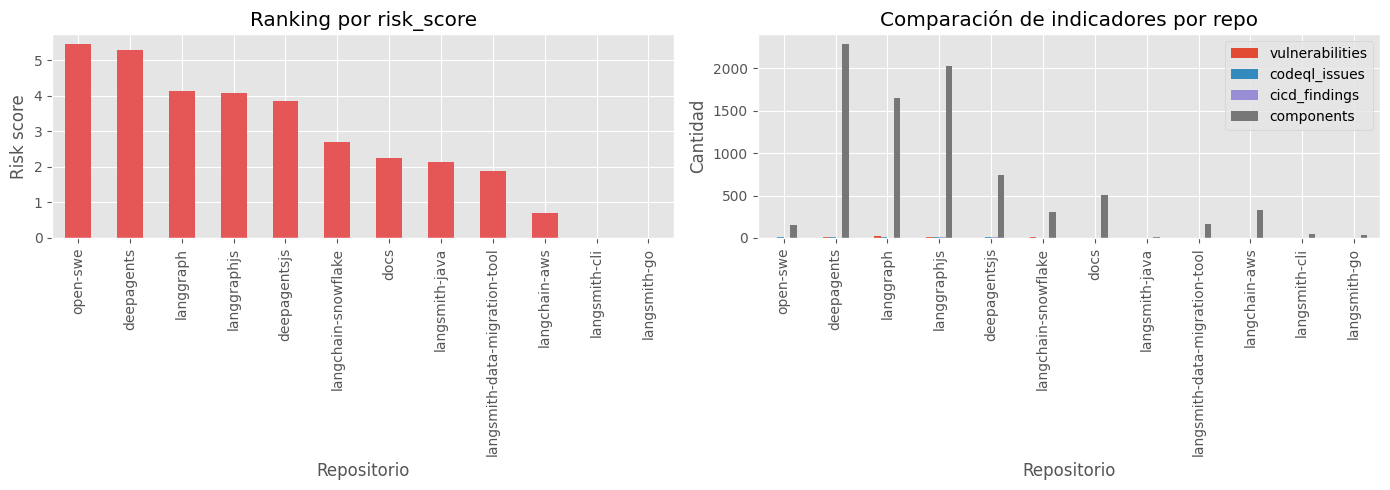

In [6]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_repo.empty:
    top = df_repo.head(15)
    top.plot.bar(x='name', y='risk_score', ax=axes[0], legend=False, color='#E45756')
    top.set_index('name')[['vulnerabilities', 'codeql_issues', 'cicd_findings', 'components']].plot(kind='bar', ax=axes[1])
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'Sin datos', ha='center', va='center')

axes[0].set_title('Ranking por risk_score')
axes[0].set_xlabel('Repositorio')
axes[0].set_ylabel('Risk score')
axes[1].set_title('Comparación de indicadores por repo')
axes[1].set_xlabel('Repositorio')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Hallazgos CI/CD (Análisis Bonus)

### Cómo interpretar esta sección
Los hallazgos CI/CD son **análisis secundario de menor prioridad**: no afectan el risk_score principal.
Agregan contexto operacional (secretos, permisos, acciones inseguras, etc.) pero no representan vulnerabilidades directas del software.

### Por qué importa en ciberseguridad
Un pipeline inseguro puede amplificar impacto incluso cuando el código de aplicación no presenta el mayor número de issues.


In [7]:
df_cicd

,repo,workflow,issue
0,deepagents,evals.yml,Permiso 'contents: write' innecesario
1,deepagents,release_please_parse_check.yml,Job 'parse-check': usa 'npm install' en vez de...
2,deepagentsjs,ci.yml,Job 'format': usa 'npm install' en vez de 'npm...
3,deepagentsjs,ci.yml,Job 'lint': usa 'npm install' en vez de 'npm c...
4,deepagentsjs,ci.yml,Job 'build': usa 'npm install' en vez de 'npm ...
5,deepagentsjs,ci.yml,Job 'test': usa 'npm install' en vez de 'npm c...
6,deepagentsjs,ci.yml,Job 'test-int': usa 'npm install' en vez de 'n...
7,deepagentsjs,cli-release.yml,Job 'build': usa 'npm install' en vez de 'npm ...
8,deepagentsjs,cli-release.yml,Job 'publish': usa 'npm install' en vez de 'np...
9,deepagentsjs,release.yml,Job 'release': usa 'npm install' en vez de 'np...


In [8]:
# Conclusiones dinámicas
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_totals = {level: 0 for level in severity_order}

for repo in analysis.get('repositories', []) or []:
    by_sev = repo.get('vulnerabilities', {}).get('by_severity', {}) or {}
    for level in severity_order:
        try:
            severity_totals[level] += int(by_sev.get(level, 0) or 0)
        except (TypeError, ValueError):
            pass

top_repo = 'N/A'
top_risk = 0.0
if not df_repo.empty:
    top_repo = str(df_repo.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repo.iloc[0].get('risk_score', 0.0) or 0.0)

most_common_severity = max(severity_totals, key=severity_totals.get) if severity_totals else 'Unknown'
total_high_critical = severity_totals.get('High', 0) + severity_totals.get('Critical', 0)
total_cicd = int(df_repo['cicd_findings'].sum()) if 'cicd_findings' in df_repo else 0

cwe_ranking = analysis.get('cross_repo_analysis', {}).get('common_weakness_ranking', []) or []
common_cwe = cwe_ranking[0]['cwe'] if cwe_ranking else 'N/A'

rule_counts = {}
for repo in analysis.get('repositories', []) or []:
    for rule_id, count in (repo.get('codeql', {}).get('by_rule', {}) or {}).items():
        try:
            rule_counts[rule_id] = rule_counts.get(rule_id, 0) + int(count or 0)
        except (TypeError, ValueError):
            continue
common_rule = max(rule_counts, key=rule_counts.get) if rule_counts else 'N/A'

print('Conclusiones dinámicas (riesgo y cierre):')
print(f'- Repo con mayor riesgo: {top_repo} ({top_risk:.2f})')
print(f'- Severidad predominante: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')
print(f'- CWE más común: {common_cwe}')
print(f'- Regla CodeQL más común: {common_rule}')

Conclusiones dinámicas (riesgo y cierre):
- Repo con mayor riesgo: open-swe (5.45)
- Severidad predominante: Medium
- Total High/Critical: 12
- Total hallazgos CI/CD: 20
- CWE más común: CWE-400
- Regla CodeQL más común: js/file-system-race


## Top 5 Mitigaciones Accionables

Vulnerabilidades Critical/High con fix disponible — priorización directa para el equipo de desarrollo.


In [9]:
mitigation_rows = []
for repo in analysis.get('repositories', []) or []:
    repo_name = repo.get('name', 'unknown')
    for item in repo.get('vulnerabilities', {}).get('items', []) or []:
        sev = str(item.get('severity', '') or '').strip().lower()
        if sev not in ('critical', 'high'):
            continue
        if not item.get('fix_available', False):
            continue
        mitigation_rows.append({
            'repo': repo_name,
            'id': item.get('id', ''),
            'severity': item.get('severity', 'Unknown'),
            'artifact': item.get('artifact', ''),
            'artifact_version': item.get('artifact_version', ''),
            'cwe': item.get('cwe', 'Unknown'),
            'fix_available': True,
        })

df_mitigations = pd.DataFrame(mitigation_rows)
if not df_mitigations.empty:
    sev_order = {'critical': 0, 'high': 1}
    df_mitigations['_sev_rank'] = df_mitigations['severity'].str.lower().map(sev_order).fillna(2)
    df_mitigations = df_mitigations.sort_values('_sev_rank').drop(columns=['_sev_rank']).head(5).reset_index(drop=True)
    display(df_mitigations)
    print(f"\nTotal Critical/High con fix: {len(mitigation_rows)}")
    print(f"Top 5 mostradas arriba — acción directa: actualizar los artifacts listados.")
else:
    print('No se encontraron vulnerabilidades Critical/High con fix disponible.')


,repo,id,severity,artifact,artifact_version,cwe,fix_available
0,deepagents,GHSA-r75f-5x8p-qvmc,Critical,litellm,1.83.0,NaN,True
1,langgraphjs,GHSA-xq3m-2v4x-88gg,Critical,protobufjs,6.11.5,CWE-94,True
2,deepagents,GHSA-v4p8-mg3p-g94g,High,litellm,1.83.0,NaN,True
3,deepagents,GHSA-jm6w-m3j8-898g,High,nltk,3.9.3,CWE-306,True
4,langchain-snowflake,GHSA-qh6h-p6c9-ff54,High,langchain-core,1.2.16,CWE-22,True



Total Critical/High con fix: 12
Top 5 mostradas arriba — acción directa: actualizar los artifacts listados.


## Limitaciones técnicas

- **CodeQL**: cobertura dependiente de build/autobuild y lenguajes del repositorio.
- **Syft/Grype**: la calidad del inventario depende de manifests y lockfiles presentes.
- **CI/CD**: visibilidad limitada a workflows detectables; análisis secundario (bonus), excluido del risk_score.
- **Temporalidad**: los resultados reflejan un corte puntual; cambian con nuevas versiones y commits.
- **Notebooks**: los notebooks 01 y 02 leen datos raw del Miner para EDA avanzado (CVSS, EPSS, fix gap), además del consolidado `analysis.json`.

## Recomendaciones
- Priorizar mitigación combinando severidad, frecuencia y capacidad de fix.
- Tratar patrones repetidos como deuda transversal (no solo local).
- Repetir ejecución periódica para seguimiento de tendencia.
- Usar `analysis.json` como fuente única para tableros y reporting.
- Explorar los notebooks 01 y 02 para análisis detallado de CVSS, EPSS y patrones de vulnerabilidad.
- Revisar la sección Top Mitigaciones para acciones inmediatas de actualización de dependencias.

## Conclusión final
Este cierre integra evidencia de dependencias, código y operación para construir una priorización defendible. El ranking por riesgo orienta dónde actuar primero y `analysis.json` habilita trazabilidad y comunicación consistente para informe o presentación ejecutiva.
